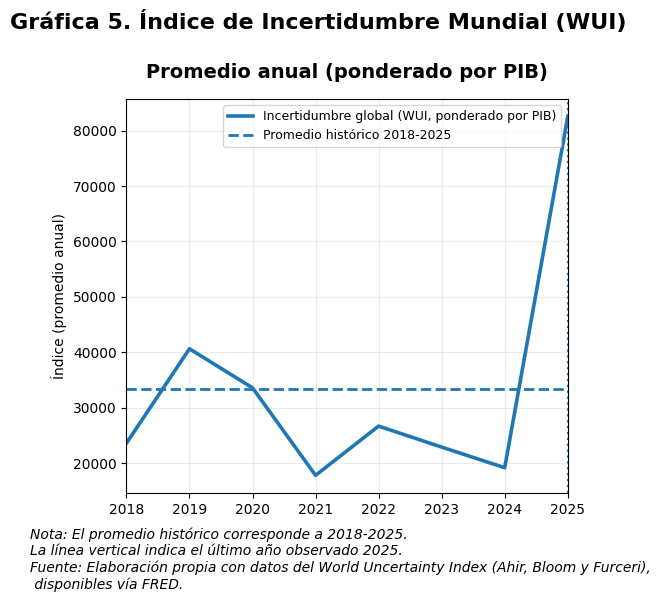

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
PATH = "raw/WUIGLOBALWEIGHTAVG.csv"   # tu archivo
HIST_START_YEAR = 2018
HIST_END_YEAR   = 2025

# =========================
# 1) Leer CSV (formato FRED)
# =========================
df = pd.read_csv(PATH)
df.columns = [c.strip() for c in df.columns]

if "observation_date" not in df.columns:
    raise ValueError(f"No encuentro 'observation_date'. Columnas: {df.columns.tolist()}")

value_col = [c for c in df.columns if c != "observation_date"][0]

df["observation_date"] = pd.to_datetime(df["observation_date"])
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
df = df.dropna(subset=[value_col]).sort_values("observation_date").copy()

# =========================
# 2) Promedio anual (robusto)
# =========================
df["year"] = df["observation_date"].dt.year
annual = df.groupby("year")[value_col].mean().rename("WUI").reset_index()

# Promedio histórico
hist = annual[(annual["year"] >= HIST_START_YEAR) & (annual["year"] <= HIST_END_YEAR)]["WUI"].mean()
anu = annual[(annual["year"] >= HIST_START_YEAR) & (annual["year"] <= HIST_END_YEAR)]
last_year = int(annual["year"].max())

# =========================
# 3) Plot estilo Banxico
# =========================
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(1, 1, figsize=(6, 6))  # antes (12.6, 4.6)


# Serie principal
ax.plot(anu["year"], anu["WUI"], linewidth=2.6, label="Incertidumbre global (WUI, ponderado por PIB)")

# Promedio histórico
ax.axhline(hist, linestyle="--", linewidth=2, label=f"Promedio histórico {HIST_START_YEAR}-{HIST_END_YEAR}")

# Línea vertical último año observado
ax.axvline(last_year, linestyle=":", linewidth=1.6)

# Estética
ax.grid(True, alpha=0.25)
ax.set_xlim(anu["year"].min(), anu["year"].max())
ax.set_ylabel("Índice (promedio anual)")
ax.set_xlabel("")  # como tus figuras
ax.set_title("Promedio anual (ponderado por PIB)", fontsize=14, fontweight="bold", pad=15)
# Leyenda
ax.legend(loc="upper right", frameon=True)

# Título (2 líneas)
fig.suptitle(
    "Gráfica 5. Índice de Incertidumbre Mundial (WUI)"
    "",
    fontsize=16, fontweight="bold", y=0.95
)

# Nota al pie
nota = (
    f"Nota: El promedio histórico corresponde a 2000-2025. "
    f"La línea vertical indica el último año observado ().", 
)
fuente = "Fuente: Elaboración propia con datos del World Uncertainty Index (Ahir, Bloom y Furceri), disponibles vía FRED."

fig.text(
    0.02, -0.02,
    "Nota: El promedio histórico corresponde a 2018-2025. \n"
    "La línea vertical indica el último año observado 2025. \n"
    "Fuente: Elaboración propia con datos del World Uncertainty Index (Ahir, Bloom y Furceri), \n disponibles vía FRED.",
     va="bottom", fontsize=10, style="italic"
)

plt.tight_layout(rect=[0.03, 0.08, 0.97, 0.95])
plt.show()
